# Additional filters based on contact area to the peptide and overall structure similarity among the backbones

Here's a summary of backbone filtering in Round 2

| Tier | partial_T | Input | Pass        | Failed clashes | Failed contacts |
|------|-----------|-------|-------------|----------------|-----------------|
| 1    | 12        | 700   | 659 (94.1%) | 6              | 35              |
| 2    | 20        | 400   | 353 (88.3%) | 39             | 10              |
| 3    | 50        | 200   | 178 (89.0%) | 19             | 3               |
| **total**|           | **1300**  | **1190 (91.5%)**| **64**             | **48**              |


To save on compute, maintain the following filters
- ~Peptide contact area quantification (CMS) — you have proximity, but have you computed actual contact molecular surface restricted to the peptide only? Backbones that are "near" the peptide but contact primarily the MHC scaffold are a known failure mode in this project specifically.~ (can't do this due to instable pyrosetta for InterfaceAnalyzer)
- Buried surface area / interface size — radius of gyration catches extended backbones but doesn't directly assess interface quality. Changes: explicitly define the peptide (not chain C) and check on the isolated peptide pose before calculating SASA.
- Backbone diversity clustering — Changes: Trim down similar backbones from partial diffusions of different starting backbones from Round 1. The output backbones are similar by design so clustering will naturally group them together and pick one medoid. No need for a pre-clustering step to handle within-backbone redundancy. **Representative selection uses medoid** (minimum mean RMSD to cluster members) rather than just the first member, which gives a more geometrically central representative. This is to prevent different starting backbones from converging.

Running these pre-MPNN could meaningfully reduce your 1190 backbones further and improve the quality of what enters the MPNN stage.

In [14]:
import pyrosetta
from pyrosetta import *
from pyrosetta.rosetta.core.scoring.sasa import SasaCalc
import glob
import pandas as pd
import matplotlib.pyplot as plt
init("-mute all -ignore_unrecognized_res true")

from os import symlink, makedirs
import os

┌───────────────────────────────────────────────────────────────────────────────┐
│                                  PyRosetta-4                                  │
│               Created in JHU by Sergey Lyskov and PyRosetta Team              │
│               (C) Copyright Rosetta Commons Member Institutions               │
│                                                                               │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRES PURCHASE OF A LICENSE │
│          See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└───────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2026 [Rosetta PyRosetta4.Release.python311.ubuntu 2026.03+releasequarterly.5e498f1409c68ade56c8ce5842bf79e1b02e8db4 2026-01-13T13:24:11] retrieved from: http://www.pyrosetta.org


## Compute peptide SASA

In [2]:
PEPTIDE_LEN = 9  # VVGADGVGK

def compute_peptide_buried_sasa(pdb_file, peptide_len=PEPTIDE_LEN):
    pose = pose_from_pdb(pdb_file)
 
    # Identify peptide residue indices:
    # Partial diffusion outputs have chain A (binder) + chain B (MHC+peptide).
    # Peptide = last peptide_len residues of chain B.
    chain_b_residues = [i for i in range(1, pose.total_residue() + 1)
                        if pose.pdb_info().chain(i) == "B"]
 
    if len(chain_b_residues) < peptide_len:
        raise ValueError(
            f"Chain B has only {len(chain_b_residues)} residues, "
            f"expected at least {peptide_len}."
        )
 
    peptide_residues = chain_b_residues[-peptide_len:]  # last 9 of chain B
    non_peptide      = [i for i in range(1, pose.total_residue() + 1)
                        if i not in set(peptide_residues)]
 
    sasa_calc = SasaCalc()
 
    # --- SASA of full complex ---
    sasa_calc.calculate(pose)
    per_res_sasa_complex = list(sasa_calc.get_residue_sasa())
    peptide_sasa_bound = sum(per_res_sasa_complex[i - 1] for i in peptide_residues)
 
    # --- SASA of peptide alone ---
    peptide_pose = pose.clone()
    for i in reversed(non_peptide):
        peptide_pose.delete_residue_slow(i)
 
    if peptide_pose.total_residue() == 0:
        raise ValueError("Peptide pose is empty after deletion — check chain layout.")
 
    sasa_calc.calculate(peptide_pose)
    peptide_sasa_free = sum(sasa_calc.get_residue_sasa())
 
    buried = peptide_sasa_free - peptide_sasa_bound
    fraction_buried = buried / peptide_sasa_free if peptide_sasa_free > 0 else 0
 
    return buried, peptide_sasa_free, peptide_sasa_bound, fraction_buried

In [3]:
results = []
pdb_files = sorted(glob.glob("/n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier*_filtered/*.pdb"))
print(f"Processing {len(pdb_files)} backbones...")

for pdb in pdb_files:
    try:
        buried, free, bound, fraction = compute_peptide_buried_sasa(pdb)
        results.append({
            "pdb": pdb,
            "peptide_buried_sasa": buried,
            "peptide_sasa_free": free,
            "peptide_sasa_bound": bound,
            "fraction_buried": buried / free if free > 0 else 0
        })
    except Exception as e:
        print(f"  Failed: {pdb} — {e}")

df = pd.DataFrame(results).sort_values("peptide_buried_sasa", ascending=False)
df.to_csv("r2_peptide_sasa_scores.csv", index=False)
print(f"\nDone. {len(df)} structures processed.")
print(f"Fraction buried — mean: {df['fraction_buried'].mean():.3f}, "
      f"min: {df['fraction_buried'].min():.3f}, "
      f"max: {df['fraction_buried'].max():.3f}")

Processing 1190 backbones...

Done. 1190 structures processed.
Fraction buried — mean: 0.855, min: 0.788, max: 0.922


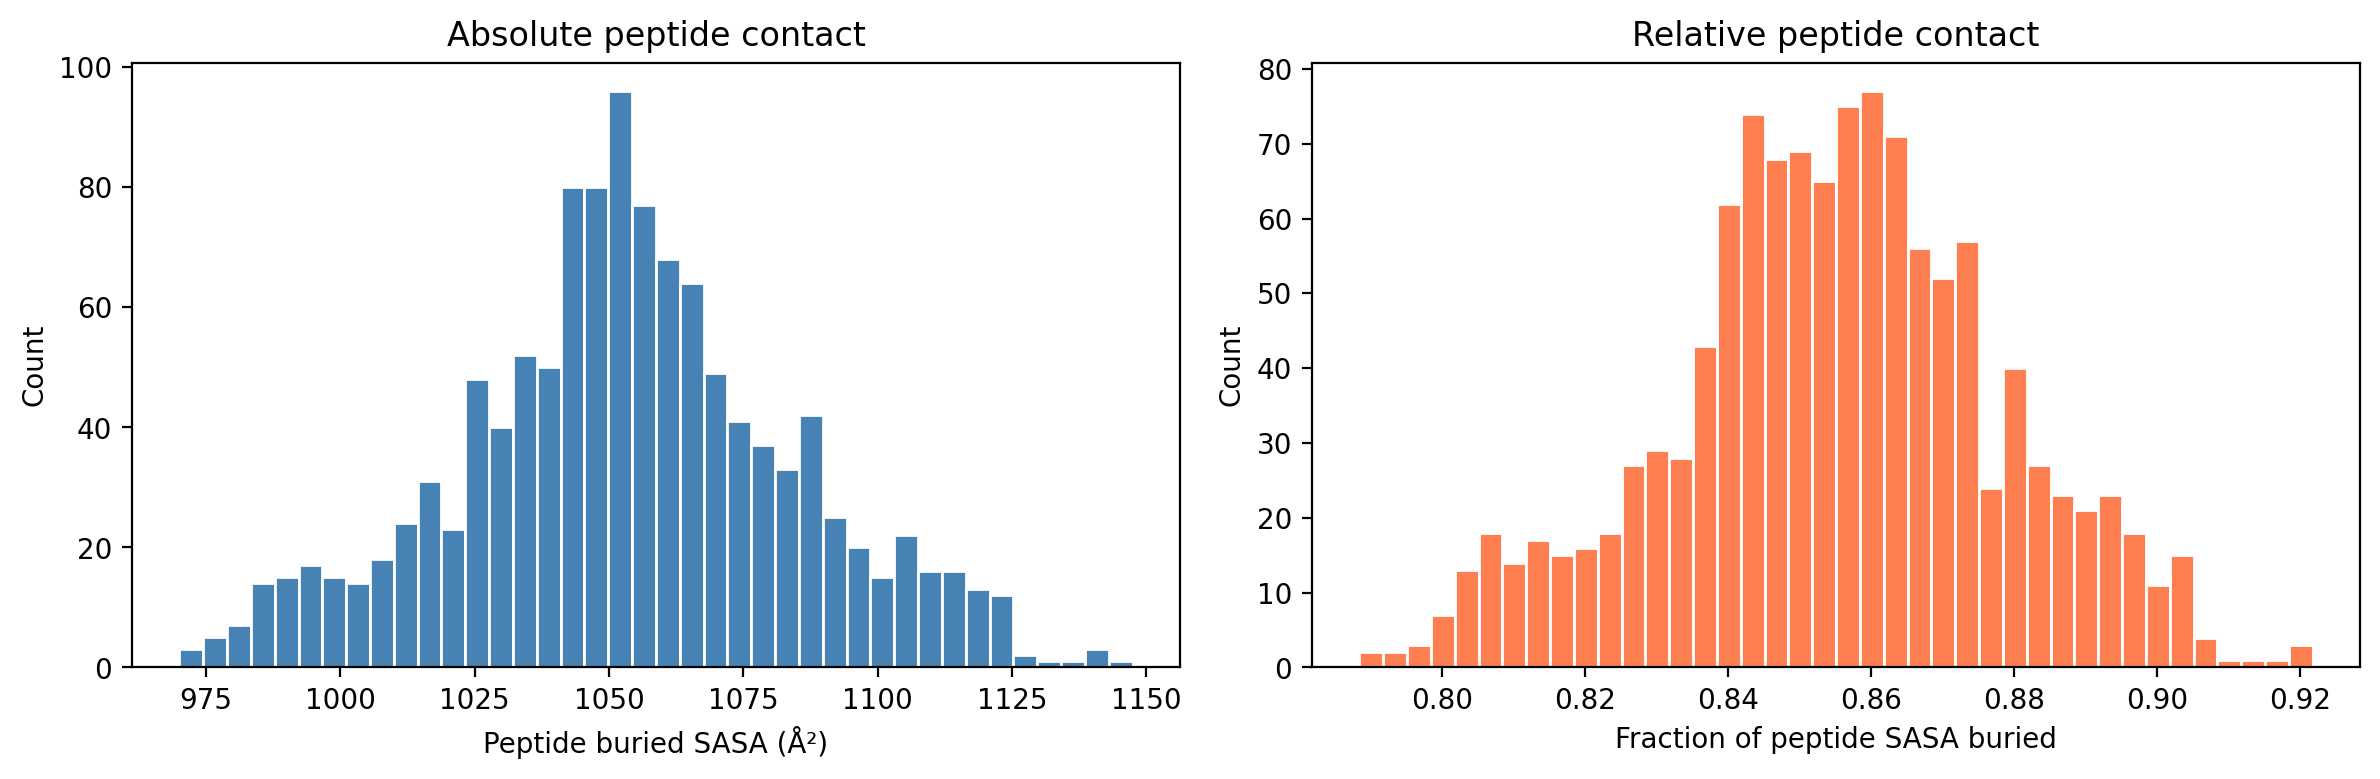


Stats:
       peptide_buried_sasa  fraction_buried
count          1190.000000      1190.000000
mean           1053.231160         0.854859
std              31.609115         0.023361
min             970.030494         0.788488
25%            1033.856578         0.841068
50%            1052.611904         0.855427
75%            1072.213474         0.870133
max            1147.483751         0.921769


In [6]:
df = pd.read_csv("r2_peptide_sasa_scores.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["peptide_buried_sasa"], bins=40,
             color="steelblue", edgecolor="white")
axes[0].set_xlabel("Peptide buried SASA (Å²)")
axes[0].set_ylabel("Count")
axes[0].set_title("Absolute peptide contact")

axes[1].hist(df["fraction_buried"], bins=40,
             color="coral", edgecolor="white")
axes[1].set_xlabel("Fraction of peptide SASA buried")
axes[1].set_ylabel("Count")
axes[1].set_title("Relative peptide contact")

plt.tight_layout()
plt.savefig("r2_peptide_sasa_distribution.png", dpi=150)
plt.show()

print("\nStats:")
print(df[["peptide_buried_sasa", "fraction_buried"]].describe())

All look good. No need to trim based on SASA.

## Cluster the backbones

In [12]:
!/n/groups/marks/users/aaron/pmhc/envs/dl_binder_design/bin/python r2_cluster_backbones.py \
    --input_dirs /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier*_filtered \
    --output_dir /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/clustered \
    --rmsd_cutoff 2.0 \
    --pattern "*.pdb"

Found 1190 filtered structures
Unique parent backbones: 25
  orient_158: 100 structures
  orient_165: 48 structures
  orient_166: 19 structures
  orient_187: 16 structures
  orient_210: 19 structures
  orient_244: 40 structures
  orient_247: 98 structures
  orient_252: 47 structures
  orient_255: 96 structures
  orient_258: 16 structures
  orient_259: 49 structures
  orient_260: 100 structures
  orient_321: 27 structures
  orient_324: 17 structures
  orient_34: 65 structures
  orient_342: 20 structures
  orient_348: 20 structures
  orient_43: 42 structures
  orient_47: 100 structures
  orient_51: 14 structures
  orient_74: 19 structures
  orient_77: 50 structures
  orient_83: 100 structures
  orient_88: 50 structures
  orient_95: 18 structures
Loading 25 backbone representatives...

Pairwise RMSD (between-backbone): min=2.59 mean=12.92 max=21.60 Å

Clustering at 2.0 Å → 25 backbones → 25 clusters

Clusters:
  [1] orient_158
  [2] orient_88
  [3] orient_247
  [4] orient_342
  [5] orient

This step is actually not necessary, as backbones were subjected to clustering with 2A as cutoff in Round 1

Create a symbolic link to all passing backbones (none filtered here)

In [16]:
filt_dir = '/n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/'
makedirs(filt_dir, exist_ok=True)

pdb_files = sorted(glob.glob("/n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier*_filtered/*.pdb"))

for pdb in pdb_files:
    file_name = pdb
    link_name = os.path.join(filt_dir, os.path.basename(file_name))
    try:
        symlink(file_name, link_name)
        print(f"Created symlink: {link_name} -> {file_name}")
    except FileExistsError:
        print("Link already exists")
    except OSError as e:
        print(f"Error: {e}")

Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_158_pT12__0.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier1_filtered/orient_158_pT12__0.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_158_pT12__1.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier1_filtered/orient_158_pT12__1.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_158_pT12__10.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier1_filtered/orient_158_pT12__10.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_158_pT12__11.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier1_filtered/orient_158_pT12__11.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r

Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_158_pT12__51.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier1_filtered/orient_158_pT12__51.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_158_pT12__52.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier1_filtered/orient_158_pT12__52.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_158_pT12__53.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier1_filtered/orient_158_pT12__53.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_158_pT12__54.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier1_filtered/orient_158_pT12__54.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/parti

Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_158_pT12__88.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier1_filtered/orient_158_pT12__88.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_158_pT12__89.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier1_filtered/orient_158_pT12__89.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_158_pT12__9.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier1_filtered/orient_158_pT12__9.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_158_pT12__90.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier1_filtered/orient_158_pT12__90.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial

Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_247_pT12__34.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier1_filtered/orient_247_pT12__34.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_247_pT12__35.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier1_filtered/orient_247_pT12__35.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_247_pT12__36.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier1_filtered/orient_247_pT12__36.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_247_pT12__37.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier1_filtered/orient_247_pT12__37.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/parti

Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_247_pT12__7.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier1_filtered/orient_247_pT12__7.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_247_pT12__70.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier1_filtered/orient_247_pT12__70.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_247_pT12__71.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier1_filtered/orient_247_pT12__71.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_247_pT12__72.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier1_filtered/orient_247_pT12__72.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial

...

Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_77_pT20__33.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier2_filtered/orient_77_pT20__33.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_77_pT20__34.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier2_filtered/orient_77_pT20__34.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_77_pT20__35.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier2_filtered/orient_77_pT20__35.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_77_pT20__36.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier2_filtered/orient_77_pT20__36.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/fi

Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_88_pT20__44.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier2_filtered/orient_88_pT20__44.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_88_pT20__45.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier2_filtered/orient_88_pT20__45.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_88_pT20__46.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier2_filtered/orient_88_pT20__46.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_88_pT20__47.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier2_filtered/orient_88_pT20__47.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/fi

Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_210_pT25__5.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier3_filtered/orient_210_pT25__5.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_210_pT25__6.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier3_filtered/orient_210_pT25__6.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_210_pT25__7.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier3_filtered/orient_210_pT25__7.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_210_pT25__8.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier3_filtered/orient_210_pT25__8.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/fi

Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_342_pT25__8.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier3_filtered/orient_342_pT25__8.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_342_pT25__9.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier3_filtered/orient_342_pT25__9.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_348_pT25__0.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier3_filtered/orient_348_pT25__0.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_348_pT25__1.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier3_filtered/orient_348_pT25__1.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/fi

Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_95_pT25__3.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier3_filtered/orient_95_pT25__3.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_95_pT25__4.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier3_filtered/orient_95_pT25__4.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_95_pT25__5.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier3_filtered/orient_95_pT25__5.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/orient_95_pT25__6.pdb -> /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/tier3_filtered/orient_95_pT25__6.pdb
Created symlink: /n/groups/marks/users/aaron/pmhc/rfdiffusion/outputs/kras/partial_r2/filtered/o